In [ ]:
import os
import sqlite3
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from scipy import signal
import librosa
import soundfile as sf

In [ ]:
db_path = "../Q3/song_fingerprints_single_peaks.db"
folder_path = '../EE200 Project Song Database/'

In [ ]:
def generate_dft(file_path):
    song, sampling_rate = librosa.load(file_path, sr=None)
    N = len(song)
    dft_complex = np.fft.fft(song)
    frequencies = np.fft.fftfreq(N, d=1/sampling_rate)

    half_N = N // 2
    positive_frequencies = frequencies[:half_N]
    magnitude_spectrum = np.abs(dft_complex[:half_N])

    plt.figure(figsize=(12, 5))
    plt.plot(positive_frequencies, magnitude_spectrum, color='b')
    plt.title(f"Discrete Fourier Transform (DFT) Magnitude Spectrum - {os.path.basename(file_path)}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
def get_spectrogram_peaks(spec, q_frequencies, q_times):
    neighborhood_size = 60
    spec_mag = 20 * np.log10(spec + 1e-10)
    threshold = np.max(spec_mag) - 60

    mask = (maximum_filter(spec_mag, size=neighborhood_size) == spec_mag)
    mask = mask & (spec_mag > threshold)
    freq_idxs, time_idxs = np.where(mask)

    peak_times = q_times[time_idxs]
    peak_frequencies = q_frequencies[freq_idxs]

    peaks = list(zip(peak_times, peak_frequencies))
    return peaks

In [ ]:
def plot_spectrogram_peaks(song_names, folder_path, nperseg):
    for song_name in song_names:
        file_path = os.path.join(folder_path, song_name + '.mp3')
        if not os.path.exists(file_path):
            file_path = f"/content/{song_name}.mp3"
            if not os.path.exists(file_path):
                file_path = f"/content/{song_name}.wav"
                if not os.path.exists(file_path):
                    print(f"Could not find audio file to make spectrogram for {song_name}")
                    continue

        song, sampling_rate = librosa.load(file_path, sr=None)
        frequencies, times, spec = signal.spectrogram(song, fs=sampling_rate, nperseg=nperseg, noverlap=256 if nperseg == 512 else 512)
        peaks = get_spectrogram_peaks(spec, frequencies, times)

        spec_db = 20 * np.log10(spec + 1e-10)

        max_display_freq = 8000
        freq_mask = frequencies <= max_display_freq
        sub_frequencies = frequencies[freq_mask]
        sub_spec_db = spec_db[freq_mask, :]

        plt.figure(figsize=(12, 5))

        plt.imshow(
            sub_spec_db,
            origin='lower',
            aspect='auto',
            cmap='viridis',
            extent=[times[0], times[-1], sub_frequencies[0], sub_frequencies[-1]],
            alpha=0.85
        )
        plt.colorbar(label='Power Intensity (dB)')

        peak_times = [p[0] for p in peaks]
        peak_frequencies = [p[1] for p in peaks]

        visible_peaks_t = []
        visible_peaks_f = []
        for t, f in zip(peak_times, peak_frequencies):
            if f <= max_display_freq:
                visible_peaks_t.append(t)
                visible_peaks_f.append(f)

        plt.scatter(visible_peaks_t, visible_peaks_f, color='red', s=12, marker='o',
                    edgecolors='black', linewidths=0.5, label='Fingerprint Peaks')

        plt.title(f"Spectrogram for song: {song_name} (nperseg={nperseg})")
        plt.ylabel('Frequency (Hz)')
        plt.xlabel('Time (seconds)')
        plt.ylim(0, max_display_freq)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

# Generating DFT for a given song

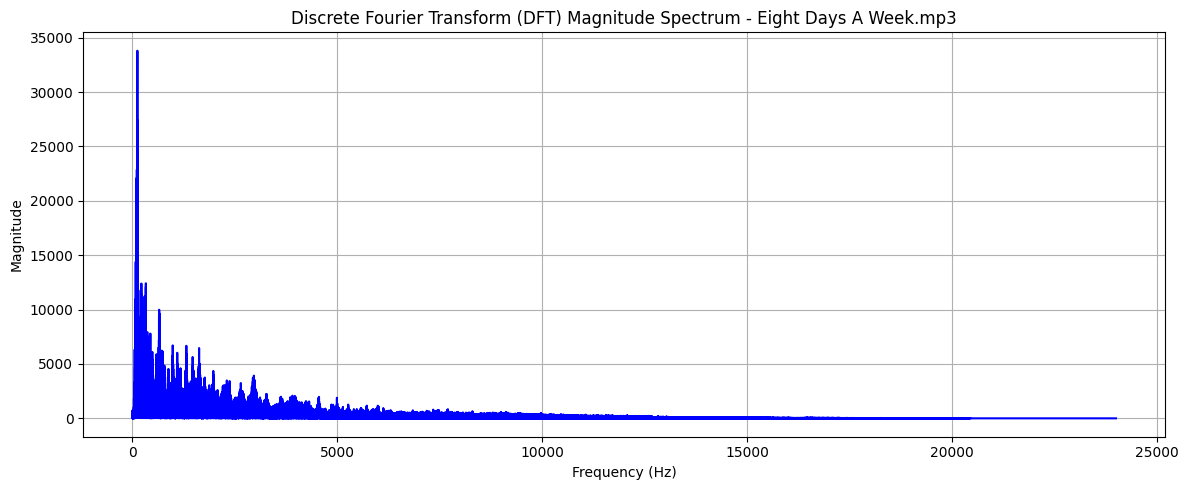

In [ ]:
generate_dft(folder_path+"Eight Days A Week.mp3")

# Plotting Spectrogram for different nperseg

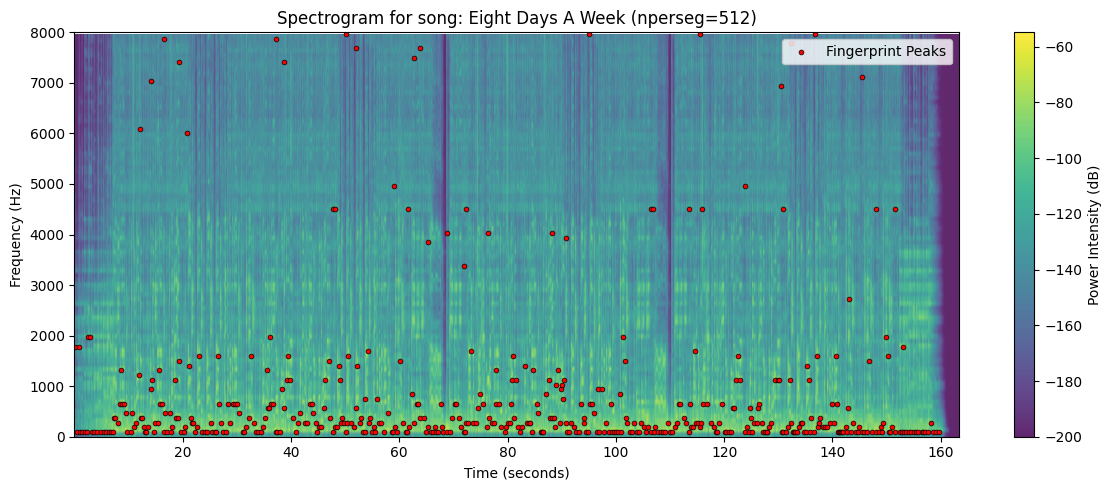

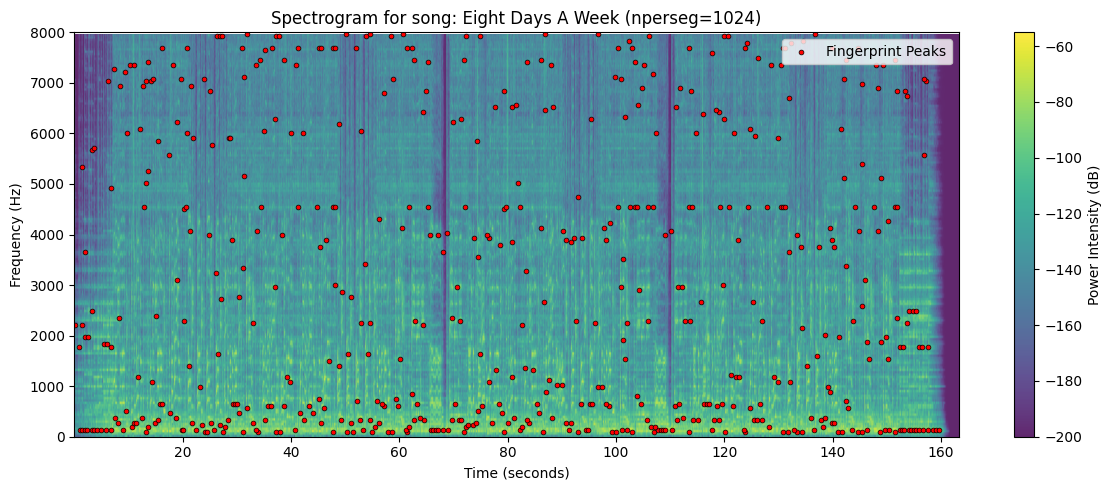

In [ ]:
for nperseg in [512, 1024]:
    plot_spectrogram_peaks(["Eight Days A Week"], folder_path, nperseg)

# Generating Database

In [ ]:
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

In [ ]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS fingerprints (
    f REAL,
    song_name TEXT,
    t REAL
)
''')

In [ ]:
cursor.execute('CREATE INDEX IF NOT EXISTS idx_hash ON fingerprints (f)')
conn.commit()
conn.close()
print("Database initialized successfully at:", db_path)

Database initialized successfully at: /content/song_fingerprints.db


In [ ]:
def add_song_to_database(peaks, song_name):
    peaks = sorted(peaks, key=lambda x: x[0])
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    insert_buffer = []

    for i in range(len(peaks)):
        t1, f1 = peaks[i]
        insert_buffer.append((round(f1, 1), song_name, round(t1, 2)))

    if insert_buffer:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.executemany('''
          INSERT INTO fingerprints (f, song_name, t)
          VALUES (?, ?, ?)
          ''', insert_buffer)
        conn.commit()
        conn.close()
        print(f"Successfully indexed '{song_name}' with {len(insert_buffer)} single peaks.")

In [ ]:
for index, song_name in enumerate(os.listdir(folder_path)):
    file_path = os.path.join(folder_path, song_name)
    clean_name = os.path.splitext(song_name)[0]

    song, sampling_rate = librosa.load(file_path, sr=None)
    frequencies, times, spec = signal.spectrogram(song, fs=sampling_rate, nperseg=1024, noverlap=512)
    peaks = get_spectrogram_peaks(spec, frequencies, times)

    add_song_to_database(peaks, clean_name)

Successfully indexed 'Never Gonna Give You Up' with 1040 single peaks.
Successfully indexed 'Hey Jude' with 2465 single peaks.
Successfully indexed 'In My Life' with 595 single peaks.
Successfully indexed 'Get Back' with 531 single peaks.
Successfully indexed 'I Saw Her Standing There' with 626 single peaks.
Successfully indexed 'Love Me Do' with 611 single peaks.
Successfully indexed 'A Day In The Life' with 786 single peaks.
Successfully indexed 'Eleanor Rigby' with 343 single peaks.
Successfully indexed 'Drive My Car' with 751 single peaks.
Successfully indexed 'Back In The U.S.S.R.' with 508 single peaks.
Successfully indexed 'Taxman' with 590 single peaks.
Successfully indexed 'Blackbird' with 278 single peaks.
Successfully indexed 'While My Guitar Gently Weeps' with 894 single peaks.
Successfully indexed 'Yesterday' with 291 single peaks.
Successfully indexed 'Can't Buy Me Love' with 547 single peaks.
Successfully indexed 'Hello, Goodbye' with 625 single peaks.
Successfully index

In [ ]:
def identify_songs(song_paths):
    query_peaks_list = []
    predicted_songs = []

    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    for idx, file_path in enumerate(song_paths):
        if not os.path.exists(file_path):
            print(f"File not found at {file_path}")
            continue

        display_name = os.path.splitext(os.path.basename(file_path))[0]
        query_song, q_sr = librosa.load(file_path, sr=None)
        q_frequencies, q_times, q_spec = signal.spectrogram(query_song, fs=q_sr, nperseg=1024, noverlap=512)

        query_peaks = get_spectrogram_peaks(q_spec, q_frequencies, q_times)
        query_peaks = sorted(query_peaks, key=lambda x: x[0])
        query_peaks_list.append(query_peaks)

        matches = {}
        winning_offsets = []

        for i in range(len(query_peaks)):
            t1_clip, f1 = query_peaks[i]
            r_f1 = round(f1, 1)

            cursor.execute('''SELECT song_name, t FROM fingerprints WHERE f = ?''', (r_f1,))

            for target_song_name, t1_db in cursor.fetchall():
                offset = round(t1_db - t1_clip, 2)
                if target_song_name not in matches:
                    matches[target_song_name] = []
                matches[target_song_name].append(offset)

        best_song = "Unknown"
        highest_match_density = 0

        if not matches:
            print(f"Result for Clip {idx+1} '{display_name}': No single peaks matched.")
            predicted_songs.append(best_song)
            continue

        for target_song_name, offset_list in matches.items():
            counts, _ = np.histogram(offset_list, bins=200)
            max_cluster_density = np.max(counts) if len(counts) > 0 else 0

            if max_cluster_density > highest_match_density:
                highest_match_density = max_cluster_density
                best_song = target_song_name
                winning_offsets = offset_list

        if highest_match_density < 10:
            print(f"Best Match for Clip {idx+1} '{display_name}'")
            predicted_songs.append("Unknown")
        else:
            print(f"Best Match for Clip {idx+1} '{display_name}'")
            predicted_songs.append(best_song)

        if winning_offsets and best_song != "Unknown":
            plt.figure(figsize=(10, 4))
            counts, bin_edges, patches = plt.hist(winning_offsets, bins=200, color='blue', edgecolor='black', alpha=0.7)
            plt.title(f"Time-Offset Alignment Histogram for Match: {best_song}")
            plt.xlabel("Time Offset (t_db - t_query) in Seconds")
            plt.ylabel("Match Density (Bin Count)")
            plt.grid(True, linestyle='--', alpha=0.5)

            peak_idx = np.argmax(counts)
            peak_count = int(counts[peak_idx])
            peak_offset = (bin_edges[peak_idx] + bin_edges[peak_idx+1]) / 2

            y_max_limit = plt.gca().get_ylim()[1]
            y_text_pos = peak_count + (y_max_limit * 0.05)
            x_text_pos = peak_offset + ((bin_edges[-1] - bin_edges[0]) * 0.04)

            plt.annotate(f'Match Peak! ({peak_count} hashes aligned at {peak_offset:.2f}s)',
                         xy=(peak_offset, peak_count),
                         xytext=(x_text_pos, y_text_pos),
                         arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

            plt.tight_layout()
            plt.show()
        else:
            print(f"No strong time-alignment histogram plotted for Clip {idx+1}.")

    conn.close()
    return (query_peaks_list, predicted_songs)

List of Songs available for testing:
Never Gonna Give You Up
Hey Jude
In My Life
Get Back
I Saw Her Standing There
Love Me Do
A Day In The Life
Eleanor Rigby
Drive My Car
Back In The U.S.S.R.
Taxman
Blackbird
While My Guitar Gently Weeps
Yesterday
Can't Buy Me Love
Hello, Goodbye
Help!
Day Tripper
Helter Skelter
Across The Universe
Eight Days A Week
You Really Got A Hold On Me
I'll Follow The Sun
I Want To Hold Your Hand
With A Little Help From My Friends
I Am The Walrus
Norwegian Wood (This Bird Has Flown)
Something
Sgt. Pepper's Lonely Hearts Club Band
Revolution
I've Got A Feeling
She Said She Said
Lucy In The Sky With Diamonds
A Hard Day's Night
Let It Be
We Can Work It Out
Penny Lane
The Long And Winding Road
Two Of Us
Within You Without You
We Will Rock You
Radio Ga Ga
Crazy Little Thing Called Love
I Want It All
We Are The Champions
Under Pressure
Don't Stop Me Now
Killer Queen
Somebody To Love
Bohemian Rhapsody
Enter the song name: I've Got A Feeling
Want to enter more? (y/n)
y

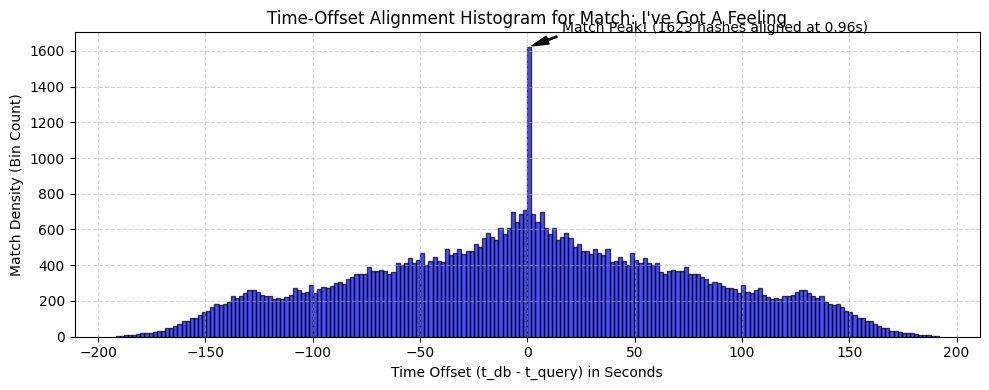

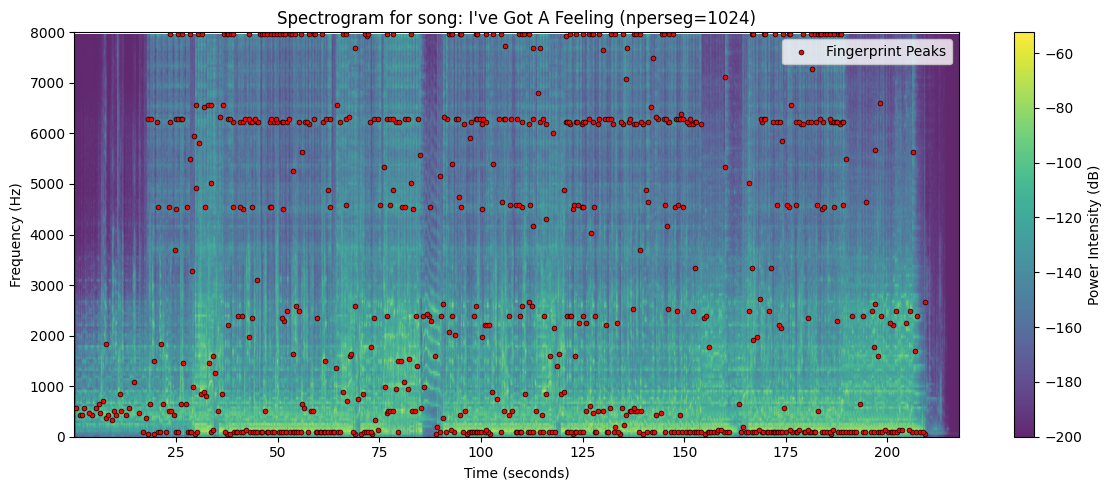

In [ ]:
song_paths = []
print("List of Songs available for testing:")
for song_name in os.listdir(folder_path):
  print(song_name[:len(song_name)-4])

choice = "y"
while(True):
  song_name = input("Enter the song name: ")
  song_paths.append(os.path.join(folder_path,song_name+'.mp3'))
  print("Want to enter more? (y/n)")
  choice = input("y/n: ")
  if(choice=="n"):
    break
print("====================================")
query_peaks_list, song_names = identify_songs(song_paths)
plot_spectrogram_peaks(song_names, folder_path, 1024)